# **Fruits-360 dataset**

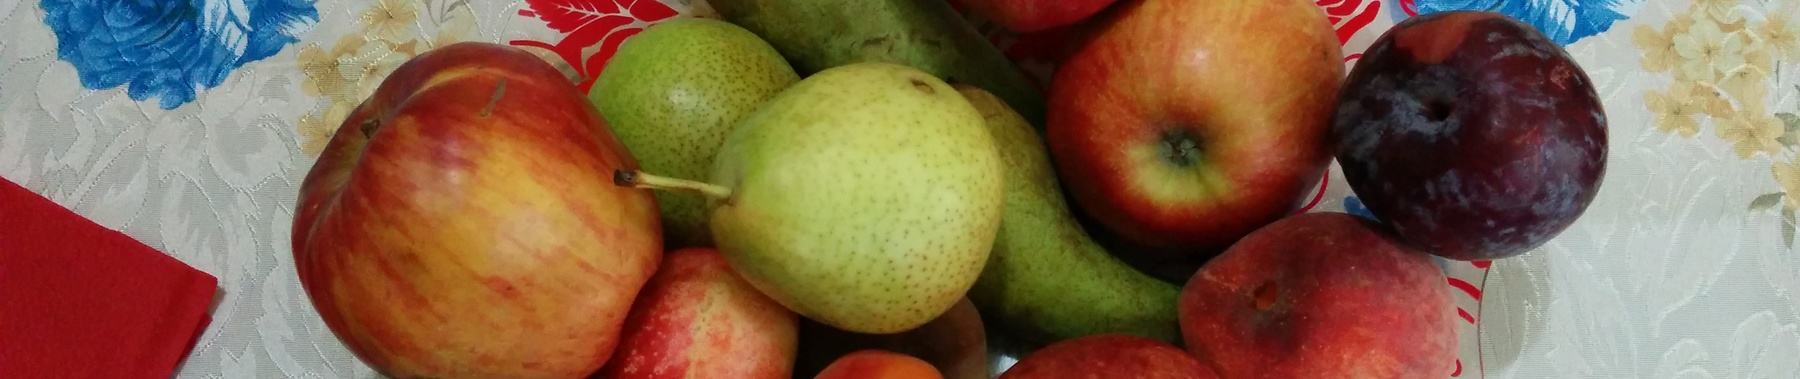

Загрузка датасета Fruits 360

In [ ]:
import kagglehub


In [ ]:
# Download latest version
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'fruits' dataset.
Path to dataset files: /kaggle/input/fruits


Импорт необходимых библиотек

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

from tensorflow.keras.preprocessing.image import ImageDataGenerator


Проверка структуры датасета

*В датасете Fruits 360 изображения распределены по папкам с названиями классов.*

In [ ]:
#Проверяем структуру
os.listdir(path)


['fruits-360_100x100',
 'fruits-360_3-body-problem',
 'fruits-360_dataset_meta',
 'fruits-360_original-size',
 'fruits-360_multi']

In [ ]:


base_path = os.path.join(path, "fruits-360_100x100", "fruits-360")
train_path = os.path.join(base_path, "Training")
test_path  = os.path.join(base_path, "Test")

os.listdir(train_path)[:10]



['Melon Piel de Sapo 1',
 'Dates 1',
 'Avocado Black 2',
 'Nectarine Flat 2',
 'Apple Crimson Snow 1',
 'Onion Red 1',
 'Cherry Wax Yellow 1',
 'Pear 10',
 'Cherry 3',
 'Avocado Green 1']

Просмотр изображений яблок и апельсинов

In [ ]:
from glob import glob
import matplotlib.pyplot as plt

# Собираем картинки из ВСЕХ подпапок Apple* и Orange*
apple_images = glob(train_path + "/Apple*/*.jpg")
orange_images = glob(train_path + "/Orange*/*.jpg")

print("Apple images:", len(apple_images))
print("Orange images:", len(orange_images))



Apple images: 16571
Orange images: 479


Выведем 5 картинок для проверки

*Яблоки*

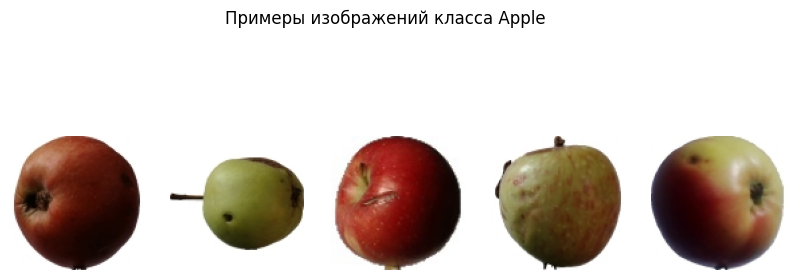

In [ ]:
import random
random.seed(42)

# Берём 5 случайных картинок
n = min(5, len(apple_images))

plt.figure(figsize=(10, 4))
for i, fp in enumerate(random.sample(apple_images, n)):
    img = plt.imread(fp)
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Примеры изображений класса Apple')
plt.show()


*Апельсины*

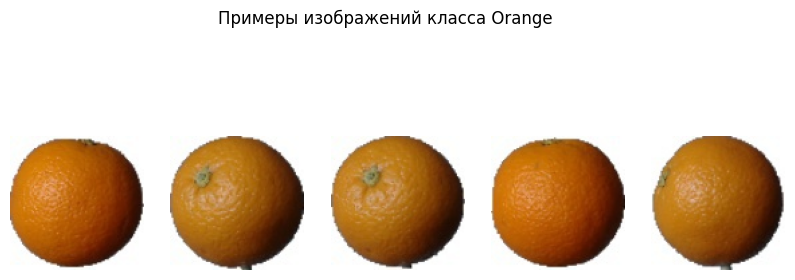

In [ ]:
n = min(5, len(orange_images))

plt.figure(figsize=(10, 4))
for i, fp in enumerate(random.sample(orange_images, n)):
    img = plt.imread(fp)
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Примеры изображений класса Orange')
plt.show()


Находим папки классов

In [ ]:
import os
import shutil
import random

random.seed(42)



# Находим все подпапки Apple* и Orange*
apple_folders = [d for d in os.listdir(train_path) if d.startswith("Apple")]
orange_folders = [d for d in os.listdir(train_path) if d.startswith("Orange")]




print("Apple folders:", len(apple_folders))
print("Orange folders:", len(orange_folders))
print("Пример Apple:", apple_folders[:5])
print("Пример Orange:", orange_folders[:5])


Apple folders: 30
Orange folders: 1
Пример Apple: ['Apple Crimson Snow 1', 'Apple 7', 'Apple Red 3', 'Apple 18', 'Apple worm 1']
Пример Orange: ['Orange 1']


Создаём структуру для бинарной классификации

In [ ]:
import shutil, os

shutil.rmtree("/content/data_binary", ignore_errors=True)

base_out = "/content/data_binary"
train_out = os.path.join(base_out, "train")
val_out = os.path.join(base_out, "val")

for cls in ["Apple", "Orange"]:
    os.makedirs(os.path.join(train_out, cls), exist_ok=True)
    os.makedirs(os.path.join(val_out, cls), exist_ok=True)

print("Создано:", train_out, "и", val_out)


Создано: /content/data_binary/train и /content/data_binary/val


Функция копирования изображений + split 80/20

In [ ]:
from glob import glob

def collect_images(source_root, folders, target_train, target_val, cls_name, val_split=0.2, max_images=None):
    all_imgs = []
    for folder in folders:
        all_imgs.extend(glob(os.path.join(source_root, folder, "*.jpg")))

    random.shuffle(all_imgs)

    if max_images is not None:
        all_imgs = all_imgs[:max_images]

    split_idx = int(len(all_imgs) * (1 - val_split))
    train_imgs = all_imgs[:split_idx]
    val_imgs = all_imgs[split_idx:]

    for fp in train_imgs:
        shutil.copy(fp, os.path.join(target_train, cls_name))
    for fp in val_imgs:
        shutil.copy(fp, os.path.join(target_val, cls_name))

    print(f"{cls_name}: всего {len(all_imgs)} | train {len(train_imgs)} | val {len(val_imgs)}")


In [ ]:
# Очищаем старые данные
shutil.rmtree("/content/data_binary", ignore_errors=True)

# заново создаём папки
for cls in ["Apple", "Orange"]:
    os.makedirs(os.path.join(train_out, cls), exist_ok=True)
    os.makedirs(os.path.join(val_out, cls), exist_ok=True)


collect_images(train_path, apple_folders, train_out, val_out, "Apple", val_split=0.2)
collect_images(train_path, orange_folders, train_out, val_out, "Orange", val_split=0.2)


Apple: всего 16571 | train 13256 | val 3315
Orange: всего 479 | train 383 | val 96


Проверяем, что всё собрано ещё раз

In [ ]:
print("Train Apple:", len(os.listdir(os.path.join(train_out, "Apple"))))
print("Train Orange:", len(os.listdir(os.path.join(train_out, "Orange"))))
print("Val Apple:", len(os.listdir(os.path.join(val_out, "Apple"))))
print("Val Orange:", len(os.listdir(os.path.join(val_out, "Orange"))))


Train Apple: 1422
Train Orange: 383
Val Apple: 1218
Val Orange: 96


Импорт библиотек

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt


Создание генераторов данных

*Используем уже подготовленные папки data_binary/train и data_binary/val*

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (100, 100)   # размер изображений Fruits 360
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_out,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_out,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

print("Классы:", train_generator.class_indices)


Found 1805 images belonging to 2 classes.
Found 1314 images belonging to 2 classes.
Классы: {'Apple': 0, 'Orange': 1}


Архитектура Модели 1

In [ ]:
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Пояснение:**
* 1 свёрточный слой — извлекает базовые признаки

* MaxPooling — уменьшает размерность

* Полносвязный слой — классификация

* Sigmoid — бинарная классификация

Компиляция модели

In [ ]:
model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


Обучение модели

In [ ]:
epochs = 10

history_1 = model_1.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    verbose=1
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8438 - loss: 0.7451 - val_accuracy: 1.0000 - val_loss: 3.3498e-04
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 2.0416e-04 - val_accuracy: 1.0000 - val_loss: 2.7799e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 1.8572e-05 - val_accuracy: 1.0000 - val_loss: 4.1728e-05
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 1.0000 - loss: 1.2315e-05 - val_accuracy: 1.0000 - val_loss: 6.1767e-06
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 6.3059e-06 - val_accuracy: 1.0000 - val_loss: 1.1598e-05
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 5.5635e-06 - val_accuracy: 1.0000 - val_loss: 6.3970e-06
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 3.8409e-06 - val_accuracy: 1.0000 - val_loss: 6.0455e-06
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 

Визуализация обучения

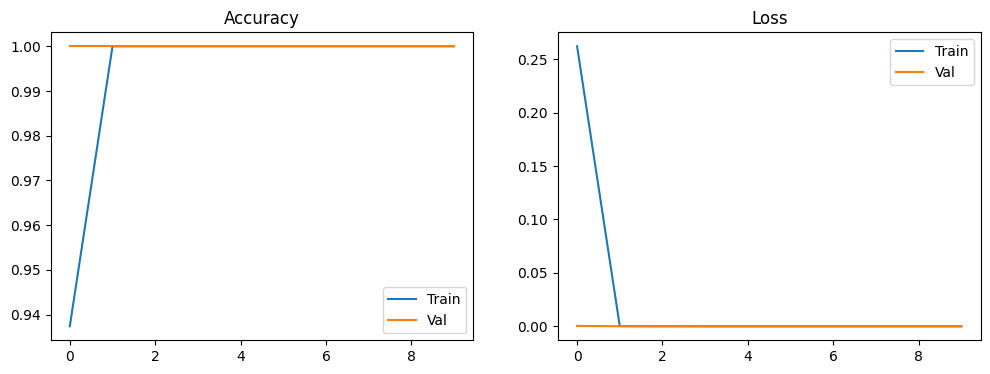

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train')
plt.plot(history_1.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()


Архитектура модели 2

**Идея:** добавить ещё 2 свёрточных блока и Dropout, чтобы:

* лучше выделять признаки

* снизить риск переобучения

* сделать «сравнение архитектур» обоснованным

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


Компиляция

In [ ]:
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


Обучение

In [ ]:
epochs = 10

history_2 = model_2.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    verbose=1
)


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8932 - loss: 0.2314 - val_accuracy: 1.0000 - val_loss: 3.5516e-04
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9978 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 1.3482e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 1.0000 - loss: 6.4233e-04 - val_accuracy: 1.0000 - val_loss: 6.8503e-07
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 1.9721e-04 - val_accuracy: 1.0000 - val_loss: 8.5892e-07
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 2.9417e-05 - val_accuracy: 1.0000 - val_loss: 1.2597e-06
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 8.6075e-05 - val_accuracy: 1.0000 - val_loss: 7.0516e-07
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 1.0000 - loss: 3.3015e-04 - val_accuracy: 1.0000 - val_loss: 2.8625e-06
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy

Графики обучения

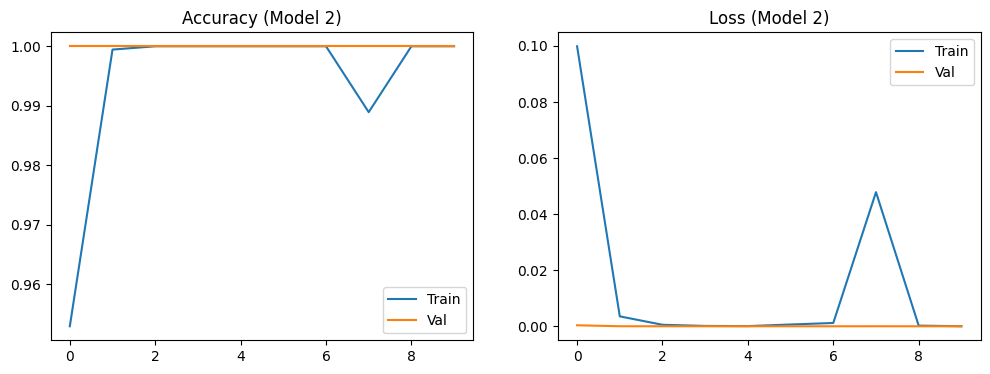

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Val')
plt.title('Accuracy (Model 2)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Val')
plt.title('Loss (Model 2)')
plt.legend()

plt.show()


Табличное сравнение моделей

In [ ]:
best_val_acc_1 = max(history_1.history['val_accuracy'])
best_val_acc_2 = max(history_2.history['val_accuracy'])

best_val_loss_1 = min(history_1.history['val_loss'])
best_val_loss_2 = min(history_2.history['val_loss'])

print("Модель 1: best val_accuracy =", best_val_acc_1, "| best val_loss =", best_val_loss_1)
print("Модель 2: best val_accuracy =", best_val_acc_2, "| best val_loss =", best_val_loss_2)


Модель 1: best val_accuracy = 1.0 | best val_loss = 3.3763915325835114e-06
Модель 2: best val_accuracy = 1.0 | best val_loss = 2.120677464745313e-07
